In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, lfilter
from plastic_neuron import PlasticNeuron
from abstract_neuron import AbstractNeuron
from neuron_utils import NeuronUtils
import itertools
import os.path

In [2]:
idx = "0"
idxs = np.arange(10)

output_dir_all = f"output/temporal-interference/poisson_delay_theta"
output_dir = f"output/temporal-interference/poisson_delay_theta/{idx}"

file_labels = {
    "0 ms": "1000/90_90_5/0",
    "25 ms": "1000/90_90_5/25",
    "50 ms": "1000/90_90_5/50",
    "75 ms": "1000/90_90_5/75",
    "100 ms": "1000/90_90_5/100",
    "125 ms": "1000/90_90_5/125",
    "150 ms": "1000/90_90_5/150",
    "175 ms": "1000/90_90_5/175"
}

# Single run analysis

## Membrane potential traces

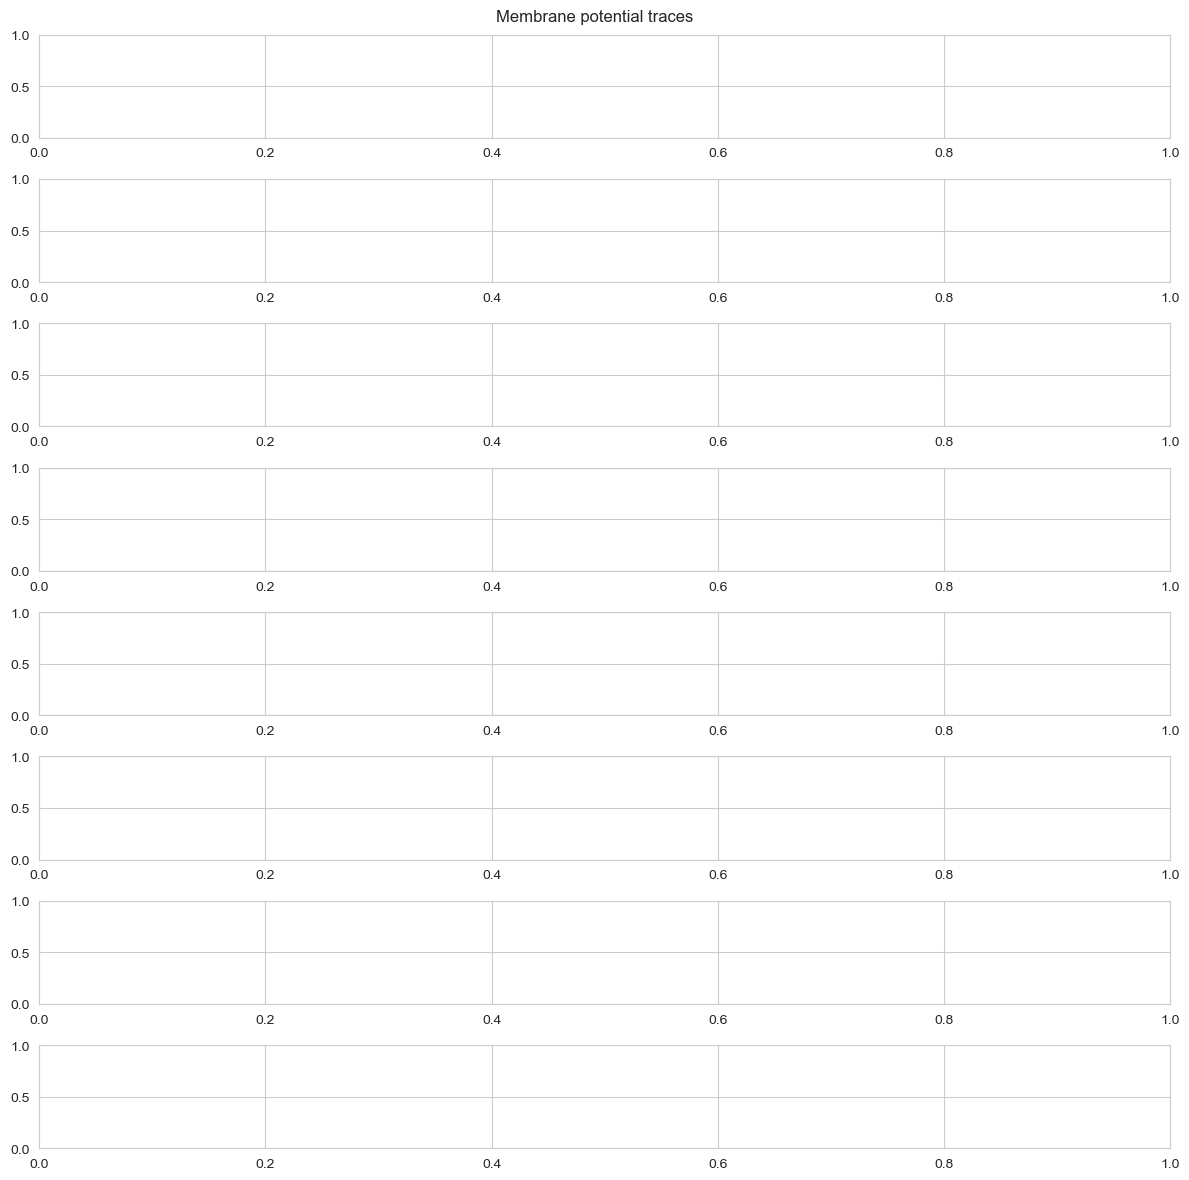

In [3]:
fig, axs = plt.subplots(nrows = len(file_labels), ncols = 1, figsize = (12, len(file_labels) * 1.5))

for i, label in enumerate(file_labels.keys()):
    filename = f"{output_dir}/{file_labels[label]}/voltage.csv"
    if not os.path.isfile(filename): continue
    
    voltage = pd.read_csv(filename)

    axs[i].plot(
        voltage.Time,
        voltage.Voltage,
        linewidth = 0.5,
        color = "black"
    )

    axs[i].set_xlabel("Time, ms")
    axs[i].set_ylabel("Voltage, mV")

    axs[i].set_xlim(4000, 7000)
    axs[i].set_ylim(-110, 70)

    axs[i].set_title(label)

fig.suptitle("Membrane potential traces")
fig.tight_layout()

plt.show()

## Spiking frequency patterns

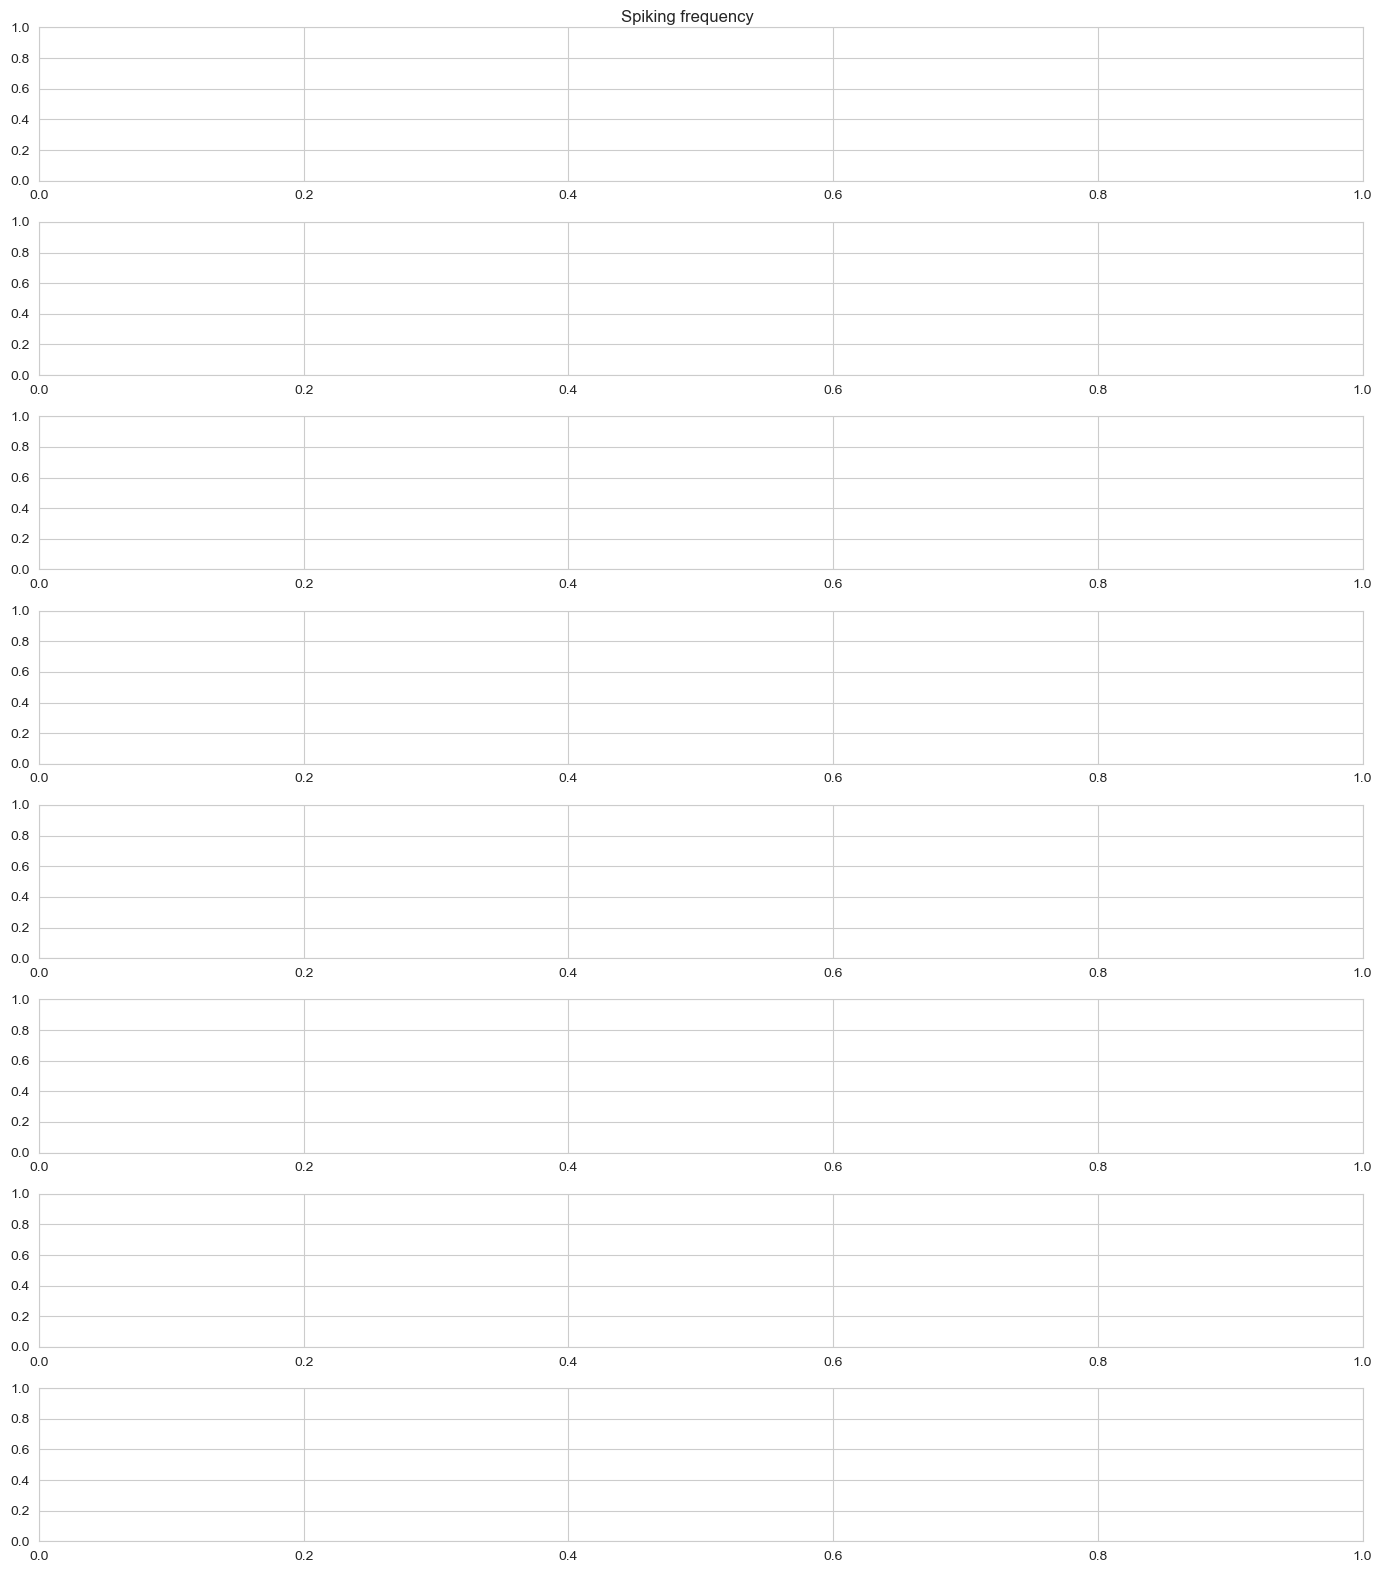

In [4]:
fig, axs = plt.subplots(nrows = len(file_labels), ncols = 1, figsize = (14, len(file_labels) * 2))

for i, label in enumerate(file_labels.keys()):
    filename = f"{output_dir}/{file_labels[label]}/spike_frequency.csv"
    if not os.path.isfile(filename): continue
    
    spike_frequency = pd.read_csv(filename)

    axs[i].scatter(
        spike_frequency.Time,
        spike_frequency.Frequency,
        s = 0.5,
        color = "black",
        zorder = 3
    )

    axs[i].grid(axis = "y", zorder = 0, alpha = 0.25)
    axs[i].set_xlabel("Time, ms")
    axs[i].set_ylabel("Frequency, Hz")
    axs[i].set_ylim(-5, 65)
    axs[i].set_yticks(np.arange(0, 65, 10))
    axs[i].set_title(label)

fig.suptitle("Spiking frequency")
fig.tight_layout()

plt.show()

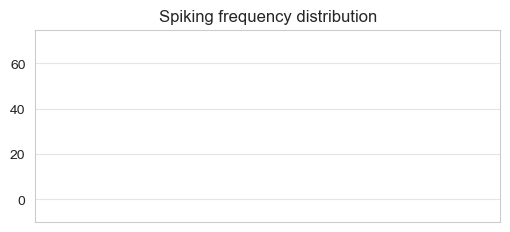

In [5]:
plt.figure(figsize = (6, 2.5))

data = []
labels = []
for i, label in enumerate(file_labels.keys()):
    filename = f"{output_dir}/{file_labels[label]}/spike_frequency.csv"
    if not os.path.isfile(filename): continue
    
    labels.append(label)
    spike_frequency = pd.read_csv(filename)
    
    data.append(spike_frequency.Frequency.values)

sns.violinplot(
    data = data,
    width = 0.5,
    zorder = 3,
    alpha = 0.75,
    inner = None,
    linewidth = 1
)

plt.xticks(np.arange(0, len(labels)), labels)
plt.ylim(-10, 75)
plt.title("Spiking frequency distribution")
plt.grid(axis = "y", zorder = 0, alpha = 0.5)

plt.show()

In [6]:
def calculate_spike_times(spike_frequency):
    spike_times = spike_frequency.Time.values
    np.insert(spike_times, 0, spike_frequency.Time[0] - 1000 / spike_frequency.Frequency[0])

    return spike_times

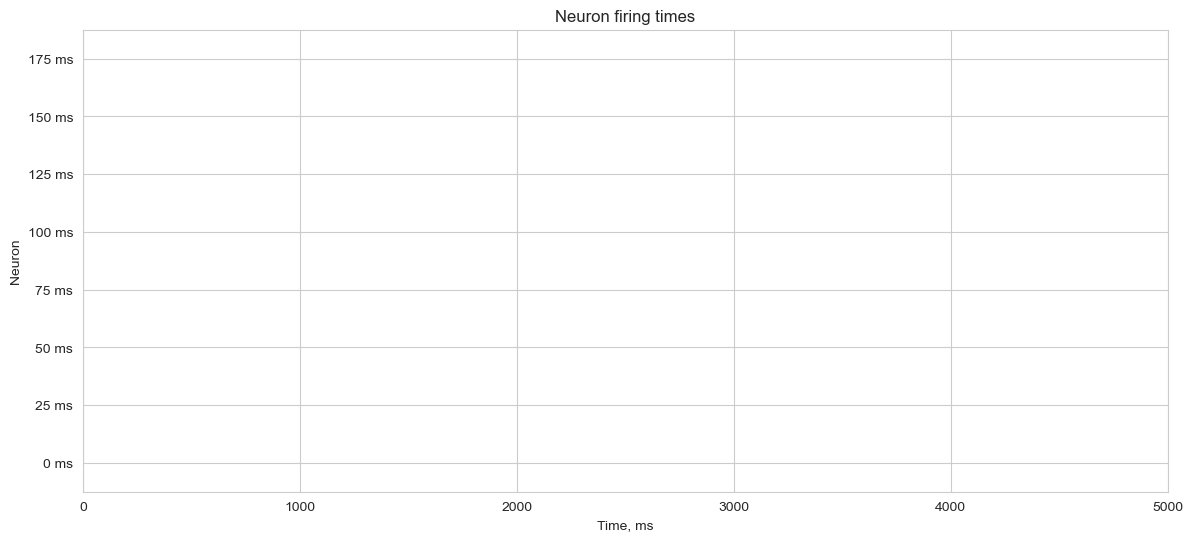

In [7]:
plt.figure(figsize = (14, len(file_labels) * 0.75))

for i, label in enumerate(file_labels.keys()):
    filename = f"{output_dir}/{file_labels[label]}/spike_frequency.csv"
    if not os.path.isfile(filename): continue
    spike_frequency = pd.read_csv(filename)
    
    if len(spike_frequency) > 0:
        spike_times = calculate_spike_times(spike_frequency)
        plt.eventplot(spike_times, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

plt.ylim(0.5, len(file_labels) + 0.5)
plt.ylabel("Neuron")
plt.yticks(np.arange(1, len(file_labels) + 1), file_labels.keys())

plt.xlabel("Time, ms")
plt.xlim(0, 5000)

plt.title("Neuron firing times")
plt.show()

# Multiple run analysis

/Users/ieva/miniconda3/envs/neuron/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/Users/ieva/miniconda3/envs/neuron/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


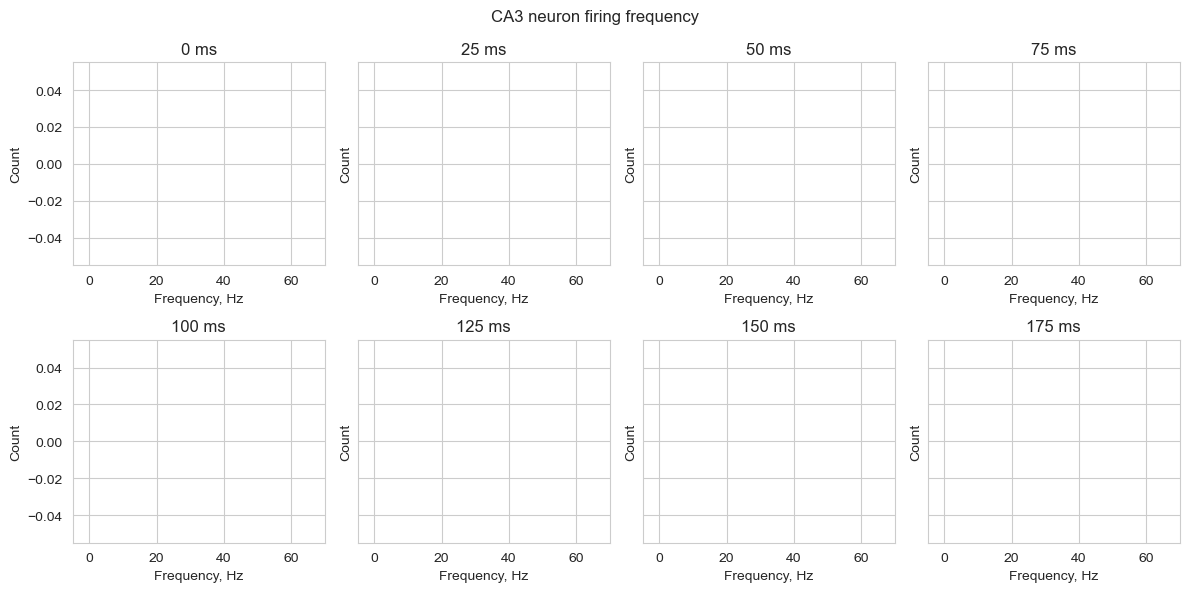

In [8]:
fig, axs = plt.subplots(nrows = 2, ncols = int(np.ceil(len(file_labels) / 2)), figsize = (12, 6), sharey = True)
axs = axs.flatten()

min = 0
max = 70

bin_edges = np.linspace(min, max, num = int(max / 2.5))

for i, label in enumerate(file_labels.keys()):
    freqs = []
    for id in idxs:
        filename = f"{output_dir_all}/{id}/{file_labels[label]}/spike_frequency.csv"
        if not os.path.isfile(filename): continue
        spike_frequency = pd.read_csv(filename).Frequency
        freqs.append(spike_frequency)

    freqs = list(itertools.chain.from_iterable(freqs))
    
    axs[i].hist(freqs, bins = bin_edges, alpha = 0.7, density = True)

    axs[i].set_ylabel("Count")
    axs[i].set_xlabel("Frequency, Hz")
    axs[i].set_xlim(-5, max)
    axs[i].set_title(label)

fig.suptitle("CA3 neuron firing frequency")
fig.tight_layout()
plt.show()

## Interspike intervals (ISI)

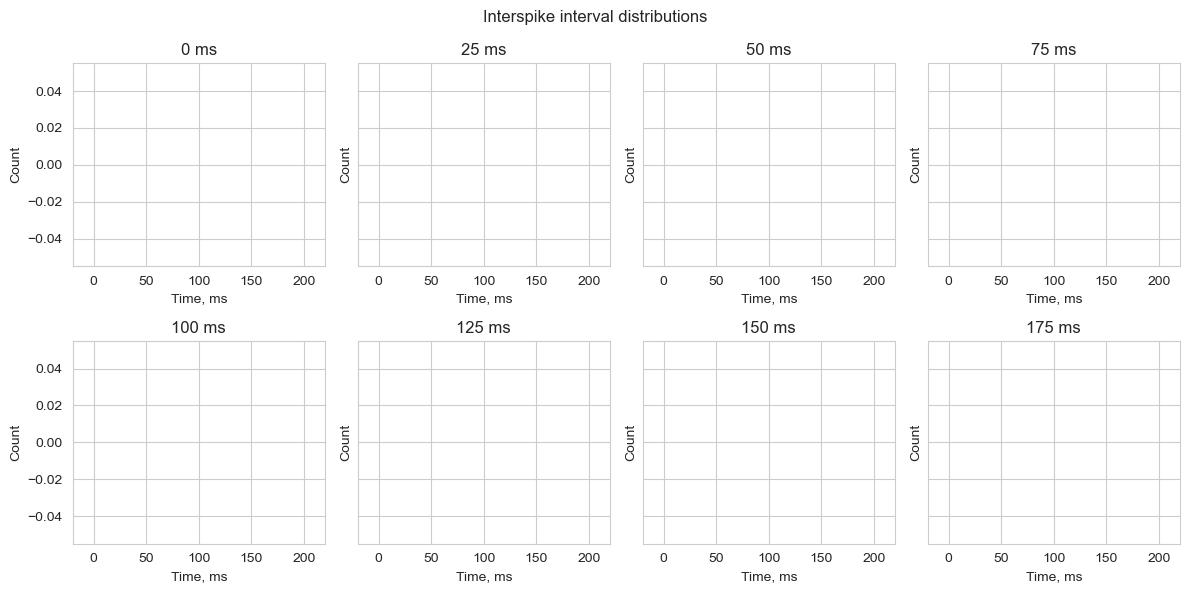

In [9]:
fig, axs = plt.subplots(nrows = 2, ncols = int(np.ceil(len(file_labels) / 2)), figsize = (12, 6), sharey = True)
axs = axs.flatten()

min = 0
max = 200

bin_edges = np.linspace(min, max, num = 50)

for i, label in enumerate(file_labels.keys()):
    isis = []
    for id in idxs:
        filename = f"{output_dir_all}/{id}/{file_labels[label]}/spike_frequency.csv"
        if not os.path.isfile(filename): continue
        spike_frequency = pd.read_csv(filename)

        if len(spike_frequency) > 0:
            spike_times = calculate_spike_times(spike_frequency)
            isi = np.diff(spike_times)
            isis.append(isi)
    
    isis = list(itertools.chain.from_iterable(isis))

    axs[i].hist(isis, bins = bin_edges, density = True, alpha = 0.75, label = label)

    axs[i].set_xlabel("Time, ms")
    axs[i].set_ylabel("Count")
    axs[i].set_title(label)
    axs[i].set_xlim(min - max * 0.1, max * 1.1)

fig.suptitle("Interspike interval distributions")
fig.tight_layout()
plt.show()

## Synaptic weights

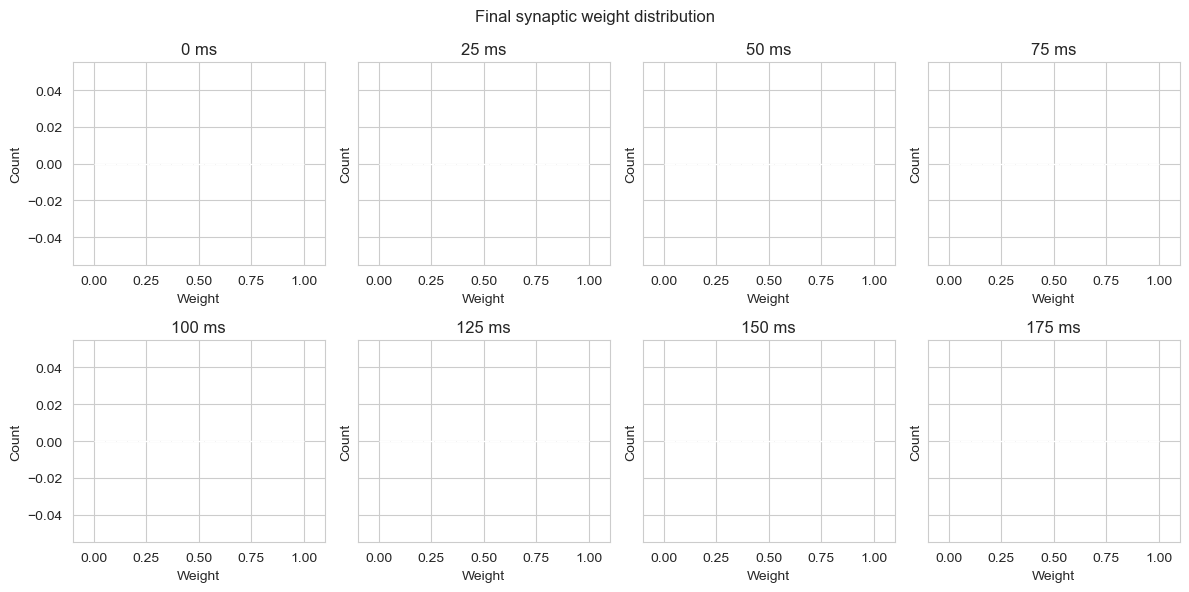

In [10]:
fig, axs = plt.subplots(nrows = 2, ncols = int(np.ceil(len(file_labels) / 2)), figsize = (12, 6), sharey = True)
axs = axs.flatten()

bin_edges = np.linspace(0, 1, num = 20)

for i, label in enumerate(file_labels.keys()):
    weights = []
    for id in idxs:
        filename = f"{output_dir_all}/{id}/{file_labels[label]}/synapse_weights.csv"
        if not os.path.isfile(filename): continue
        syn_weights = pd.read_csv(filename)
    
        synapse_weights = syn_weights.iloc[-1][2:].values
        weights.append(synapse_weights)
    
    weights = np.array(weights).flatten()

    axs[i].grid(axis = "y", zorder = 0)
    axs[i].hist(weights, zorder = 3, bins = bin_edges)
    axs[i].set_title(label)
    axs[i].set_xlabel("Weight")
    axs[i].set_ylabel("Count")
    axs[i].set_xlim(-0.1, 1.1)

fig.suptitle("Final synaptic weight distribution")
fig.tight_layout()
plt.show()

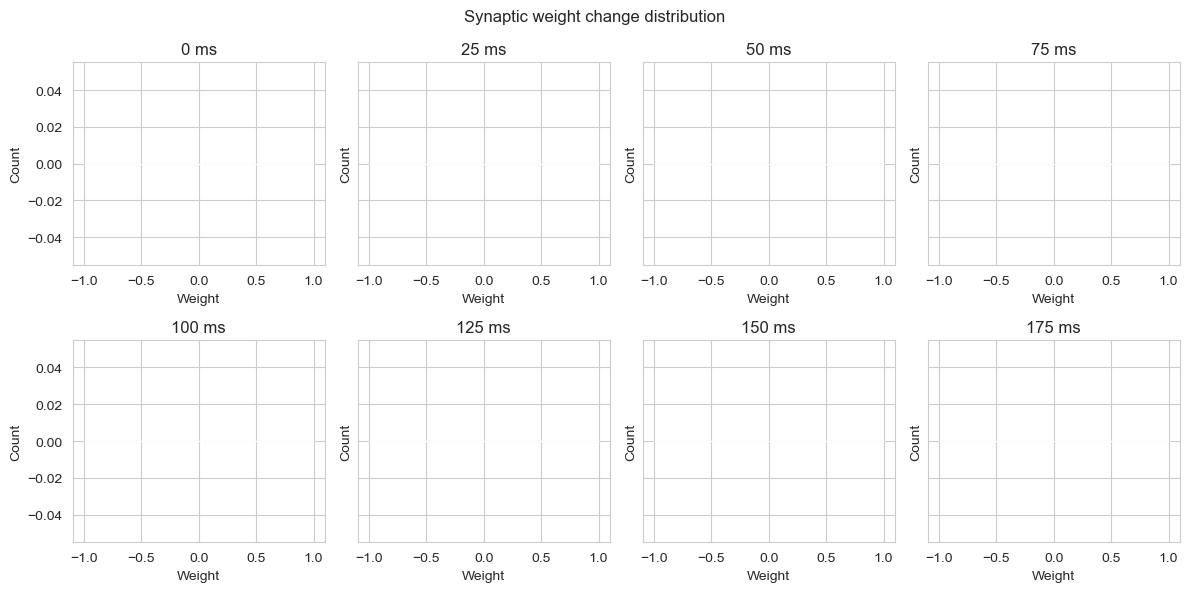

In [11]:
fig, axs = plt.subplots(nrows = 2, ncols = int(np.ceil(len(file_labels) / 2)), figsize = (12, 6), sharey = True)
axs = axs.flatten()

bin_edges = np.linspace(-1, 1, num = 20)

for i, label in enumerate(file_labels.keys()):
    weights = []
    for id in idxs:
        filename = f"{output_dir_all}/{id}/{file_labels[label]}/synapse_weights.csv"
        if not os.path.isfile(filename): continue
        syn_weights = pd.read_csv(filename)

        synapse_weights = syn_weights.iloc[-1][2:].values - syn_weights.iloc[0][2:].values
        weights.append(synapse_weights)
    
    weights = np.array(weights).flatten()

    axs[i].grid(axis = "y", zorder = 0)
    axs[i].hist(weights, zorder = 3, bins = bin_edges)
    axs[i].set_title(label)
    axs[i].set_xlabel("Weight")
    axs[i].set_ylabel("Count")
    axs[i].set_xlim(-1.1, 1.1)

fig.suptitle("Synaptic weight change distribution")
fig.tight_layout()
plt.show()

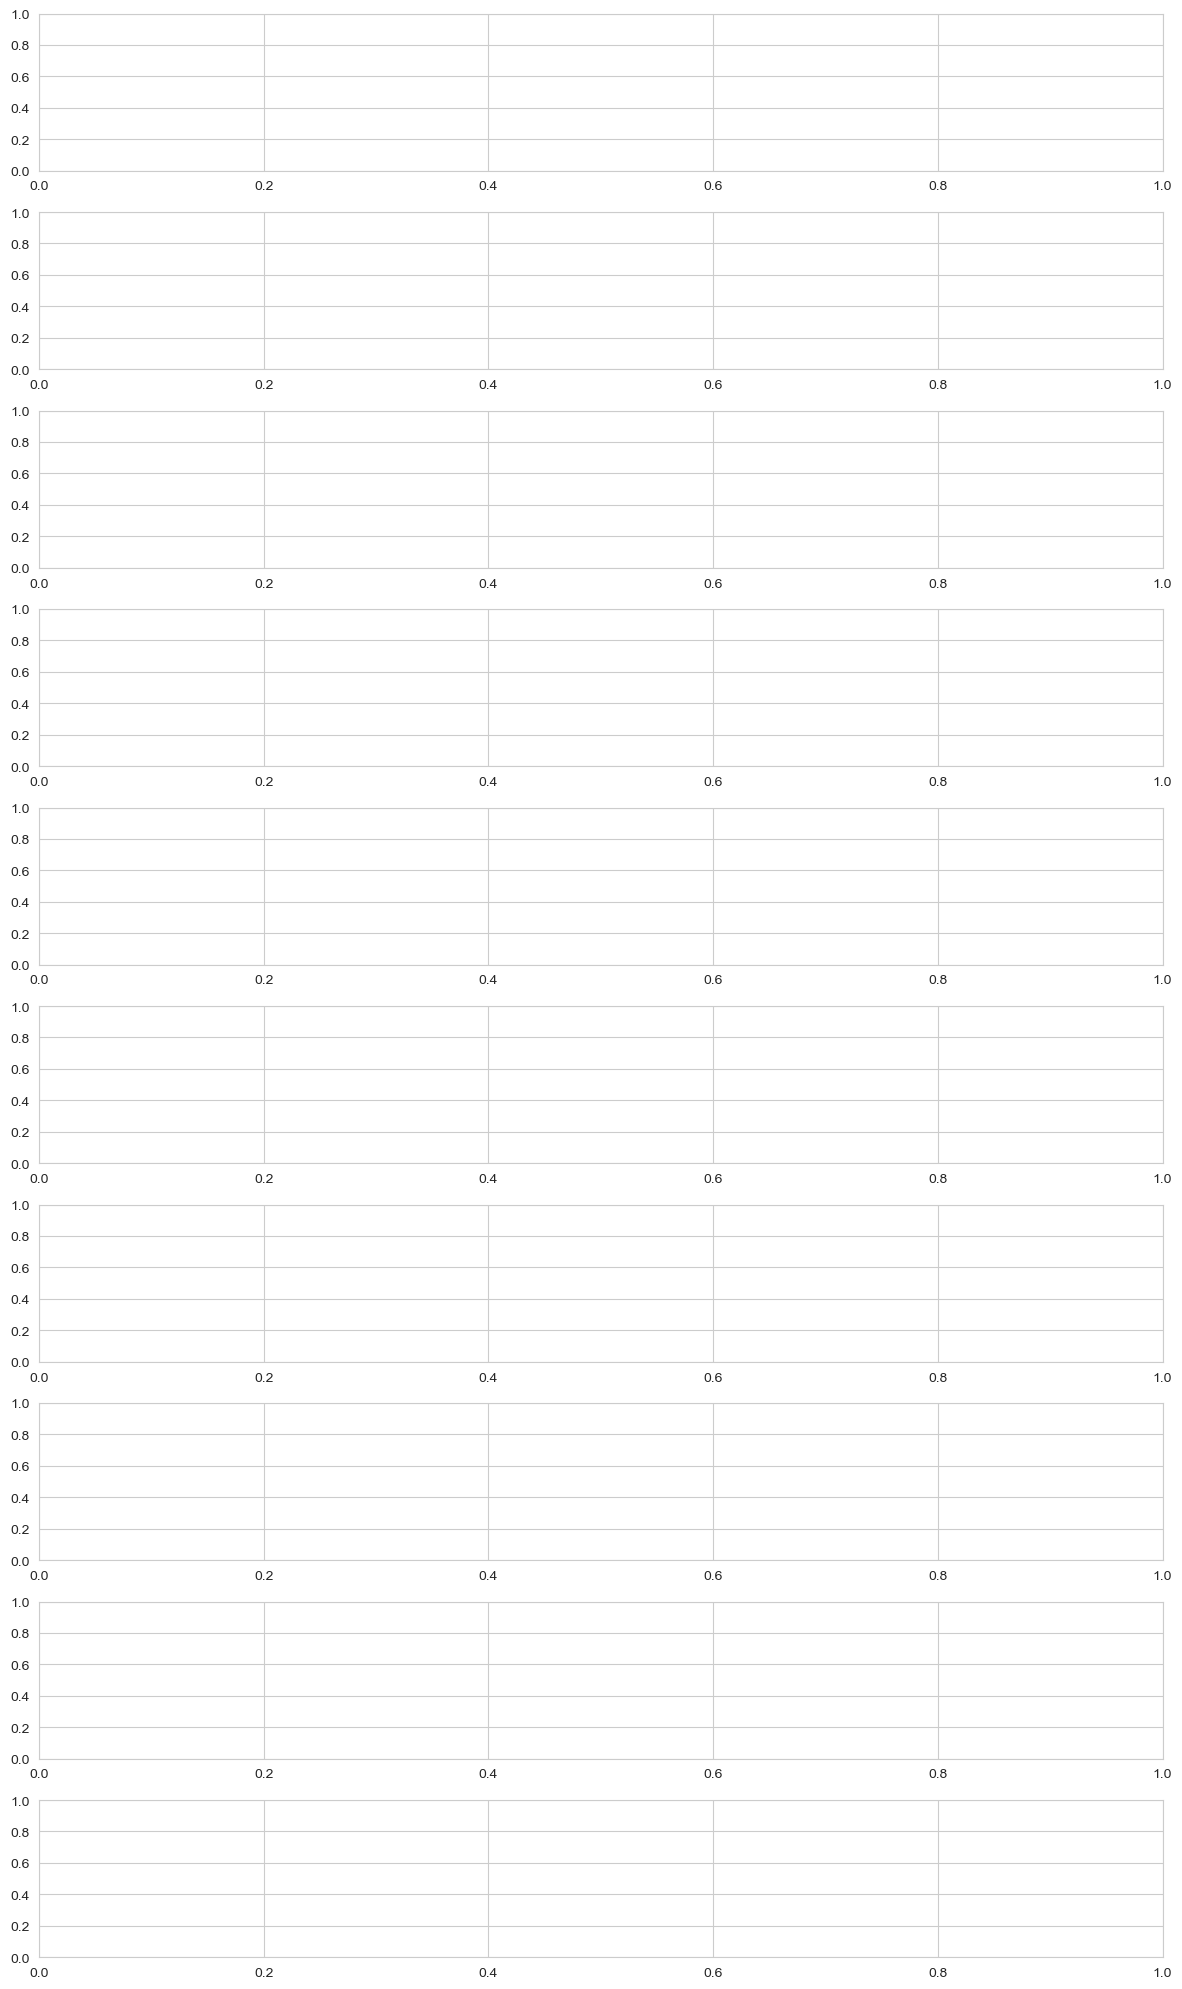

In [12]:
n_synapses = 10
fig, axs = plt.subplots(nrows = n_synapses, ncols = 1, figsize = (12, 2 * n_synapses))

for i, label in enumerate(file_labels.keys()):
    filename = f"{output_dir}/{file_labels[label]}/synapse_weights.csv"
    if not os.path.isfile(filename): continue
    syn_weights = pd.read_csv(filename)

    for j in range(n_synapses):
        axs[j].plot(syn_weights.Time, syn_weights[f"Synapse{j}"], linewidth = 0.5, label = label)
        axs[j].set_xlabel("Time, ms")
        axs[j].set_ylabel("Weight")
        axs[j].set_ylim(-0.1, 1.1)

fig.tight_layout()
plt.show()

In [13]:
def plot_correlation_line(x, y, ax):
    slope, intercept = np.polyfit(x, y, 1)
    corr = np.corrcoef(x, y)[0, 1]
    x_vals = np.arange(-0.1, 1.4, 0.1)
    y_vals = slope * x_vals + intercept

    ax.plot(
        x_vals,
        y_vals,
        color = "gray",
        label = f"R = {round(corr, 2)}"
    )


neuron = PlasticNeuron(
    n_synapses = 0
)

NeuronUtils.set_field(
    psi_deg = 90,
    phi_deg = 90
)

Creating cell
	1 
	1 
	0 
23 
After any change to cell geometry or nseg, be sure to invoke setpointers()
Generating synapse information
Inserting 0 synapses


In [14]:
def get_synapse_info(file_labels, idx = "0", key = "0 ms"):
    filename = f"{output_dir_all}/{idx}/{file_labels[key]}/synapse_weights.csv"
    if not os.path.isfile(filename): return pd.DataFrame()
    
    synaptic_weights = pd.read_csv(filename)
    initial_weights = synaptic_weights.iloc[0][2:].values
    final_weights = synaptic_weights.iloc[-1][2:].values
    
    synapse_info = pd.read_csv(f"{output_dir_all}/{idx}/{file_labels[key]}/synapse_info.csv")
    synapse_info.drop(synapse_info.columns[[0, 1]], axis = 1, inplace = True)
    
    synapse_info["InitialWeight"] = initial_weights
    synapse_info["FinalWeight"] = final_weights
    synapse_info["Angle"] = NeuronUtils.calculate_synapse_angles(synapse_info)
    synapse_info["Delay"] = key
    synapse_info["RunID"] = idx
    synapse_info["SynapseID"] = [ f"{idx}_{id}" for id in synapse_info.index ]
    synapse_info["WeightChange"] = synapse_info.FinalWeight - synapse_info.InitialWeight

    synapse_info["Delay"] = pd.Categorical(synapse_info["Delay"], categories = list(file_labels.keys()), ordered=True)
    
    return synapse_info

In [15]:
synapses = []

for id in idxs:
    for key in file_labels.keys():
        synapses.append(
            get_synapse_info(file_labels = file_labels, idx = id, key = key)
        )

synapses = pd.concat(synapses, ignore_index = True)
synapses

""


AttributeError: 'DataFrame' object has no attribute 'Delay'

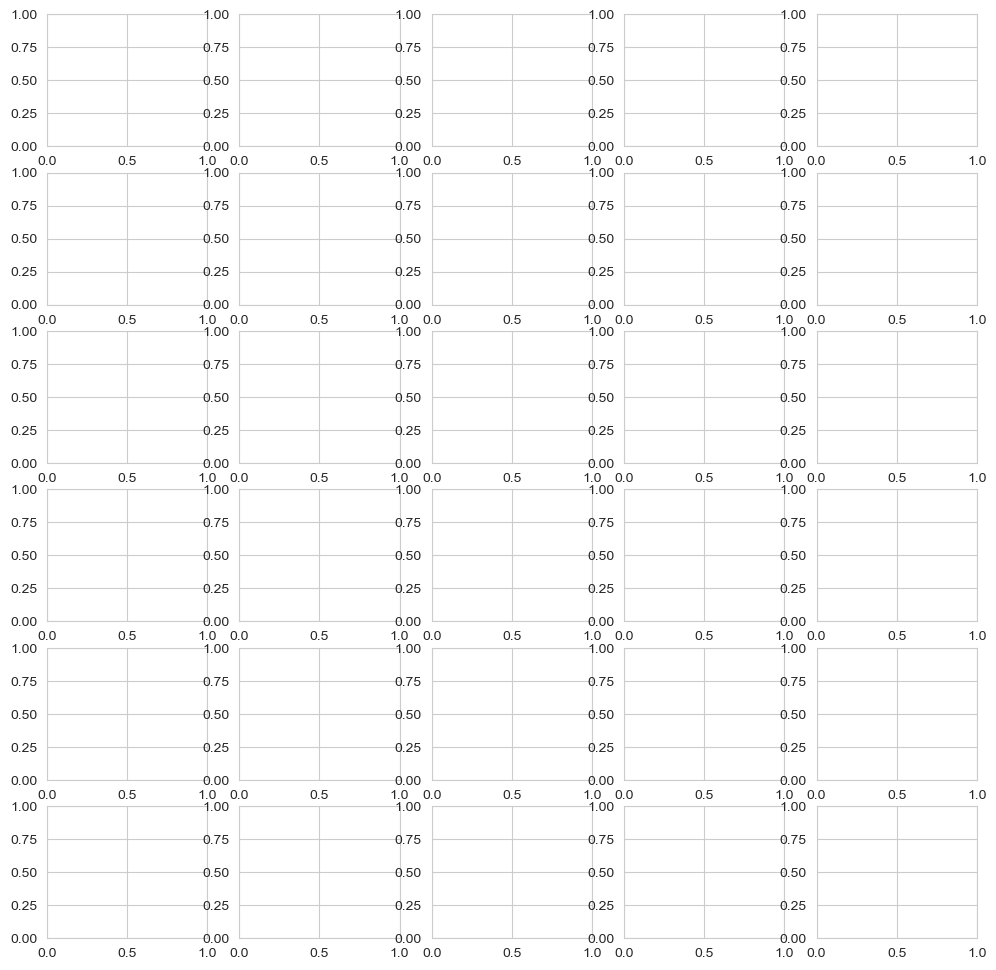

In [16]:
pairs = list(itertools.combinations(file_labels.keys(), 2))

fig, axs = plt.subplots(nrows = int(np.ceil(len(pairs) / 5)), ncols = 5, figsize = (12, 2 * np.ceil(len(pairs) / 5)))
axs = axs.flatten()

for ax, pair in zip(axs, pairs):
    x = synapses[ synapses.Delay == pair[0] ]
    y = synapses[ synapses.Delay == pair[1] ]
    
    ids = np.intersect1d(x.SynapseID.unique(), y.SynapseID.unique())
        
    x = x[ x.SynapseID.isin(ids) ].sort_values(by = "SynapseID").FinalWeight
    y = y[ y.SynapseID.isin(ids) ].sort_values(by = "SynapseID").FinalWeight

    ax.scatter(
        x,
        y,
        s = 5
    )

    plot_correlation_line(x, y, ax = ax)

    ax.set_xlabel(pair[0])
    ax.set_ylabel(pair[1])
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.15)
    ax.legend(loc = "upper right")
    ax.grid(True)

# fig.suptitle("Final synaptic weights")
fig.tight_layout()

plt.show()

In [ ]:
pairs = list(itertools.combinations(file_labels.keys(), 2))

fig, axs = plt.subplots(nrows = int(np.ceil(len(pairs) / 5)), ncols = 5, figsize = (12, 2 * np.ceil(len(pairs) / 5)))
axs = axs.flatten()

for ax, pair in zip(axs, pairs):
    x = synapses[ synapses.Delay == pair[0] ]
    y = synapses[ synapses.Delay == pair[1] ]

    ids = np.intersect1d(x.SynapseID.unique(), y.SynapseID.unique())

    x = x[ x.SynapseID.isin(ids) ].sort_values(by = "SynapseID")
    x = x.FinalWeight - x.InitialWeight
    
    y = y[ y.SynapseID.isin(ids) ].sort_values(by = "SynapseID")
    y = y.FinalWeight - y.InitialWeight

    ax.scatter(
        x,
        y,
        s = 5
    )

    plot_correlation_line(x, y, ax = ax)

    ax.set_xlabel(pair[0])
    ax.set_ylabel(pair[1])
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.15)
    ax.legend(loc = "upper right")
    ax.grid(True)

fig.suptitle("Change in synaptic weights")
fig.tight_layout()

plt.show()

In [ ]:
# Estimates locally weighted linear regression
sns.lmplot(
    synapses,
    lowess = True,
    x = "Location", y = "FinalWeight", hue = "Delay",
    scatter_kws = { "s": 5 }
)

plt.xlim(-0.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel("Location along the dendrite")
plt.ylabel("Final synaptic weight")

plt.grid(True)
plt.title("Synaptic weight change dependence on dendritic location")

plt.show()

In [ ]:
# Estimates locally weighted linear regression
sns.lmplot(
    synapses,
    lowess = True,
    x = "Location", y = "WeightChange", hue = "Delay",
    scatter_kws = { "s": 5 }
)

plt.xlim(-0.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel("Location along the dendrite")
plt.ylabel("Change in synaptic weight")

plt.grid(True)
plt.title("Synaptic weight change dependence on dendritic location")

plt.show()

## EPSPs

In [ ]:
# def causal_bandpass(data, fs, lowcut=1.0, highcut=30.0, order=2):
#     nyq = 0.5 * fs
#     low = lowcut / nyq
#     high = highcut / nyq
# 
#     b, a = butter(order, [low, high], btype='band')
#     return lfilter(b, a, data)

In [ ]:
# before_length = 50 # ms
# epsp_length = 100 # ms
# 
# fig, axs = plt.subplots(
#     nrows = 2, ncols = 5,
#     figsize = (4, 3)
# )
# axs = axs.flatten()
# 
# for i, type in enumerate(file_labels.keys()):
#     print(i)
#     filetype = file_labels[type]
# 
#     synapses_voltage = pd.read_csv(f"{output_dir}/{filetype}/synapse_voltage.csv", index_col = 0)
#     stimuli_times = pd.read_csv(f"{output_dir}/{filetype}/synapse_stimuli.csv", header = None)
# 
#     for j in range(10):
#         synapse_stimuli = np.array(stimuli_times.iloc[j].values)
#         synapse_stimuli = synapse_stimuli[~np.isnan(synapse_stimuli)]
# 
#         synapse_voltage = synapses_voltage[f"Synapse{j}"].values
#         synapse_voltage = causal_bandpass(synapse_voltage, lowcut = 1, highcut = 30, fs = int(1 / (synapses_voltage.Time[1]) * 1000), order = 2)
# 
#         volts = []
#         time = []
#         for stimulus in synapse_stimuli:
#             start = stimulus - before_length
#             end = stimulus + epsp_length
# 
#             if start < 0 or end > synapses_voltage.Time.max():
#                 continue
# 
#             idx = np.where(np.logical_and(synapses_voltage.Time >= start, synapses_voltage.Time <= end))
#             time = synapses_voltage.Time.values[idx]
#             volt = synapse_voltage[idx]
# 
#             volts.append(volt)
# 
#         volts = np.vstack(volts)
#         time = synapses_voltage[ synapses_voltage.Time < before_length + epsp_length ].Time.values
# 
#         axs[j].plot(
#             time,
#             volts.mean(axis = 0),
#             label = type
#         )
#         axs[j].set_xlabel("Time, ms")
#         axs[j].set_ylabel("Membrane potential (filtered)")
#         axs[j].set_title(f"Synapse {j + 1}")
#         axs[j].axvline(before_length, linewidth = 1, color = "black")
# 
#         axs[j].legend(loc = "center left", bbox_to_anchor = (1, 0.5))
# 
# fig.suptitle("EPSP amplitude at synapse locations")
# fig.tight_layout()
# plt.show()